In [140]:
import json
from pathlib import Path
import numpy as np
from datasets import load_from_disk
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit

In [ ]:
def load_dataset_with_metadata(ds_name: str, campaign: str = "step-analysis_001"):
    """Load dataset after ensuring offline availability."""
    dataset_path = Path("Drive") / campaign / f"{ds_name}_all_checkpoints"

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset not found: {dataset_path}")

    # Load dataset
    df = load_from_disk(str(dataset_path))
    # Load metdata
    metadata_path = dataset_path / df.info.description
    metadata = {}
    if metadata_path.exists():
        with open(metadata_path) as f:
            metadata = json.load(f)

    return df.to_pandas(), metadata

In [3]:
model_name = "pythia-12b-deduped"
df, meta = load_dataset_with_metadata(model_name)

In [129]:
weight_type = "W_QK"
stat_name = "std"
df = df.query(f"model == '{model_name}' and weight_type == '{weight_type}'")

# Get architecture dimensions
n_layers = df["layer"].max() + 1
n_heads = df["head"].max() + 1
n_steps = len(df["step"].unique())

In [120]:
def get_layer_time_series(df_i, n_heads_i=0, layer_idx=0):
    time_series = []
    steps = []
    df_i = df_i.query(f"layer == {layer_idx}")

    for head_idx in range(n_heads_i):
        df_temp = df_i.query(f"head == {head_idx}")
        df_temp = df_temp.sort_values("step")
        time_series.append(df_temp[stat_name].to_numpy())
    if len(steps) < 1:
        steps = df_temp["step"].to_numpy()
    return np.array(time_series), steps

## UMAP Reduction

Kmeans used for visuals

/opt/anaconda3/envs/llm-work/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


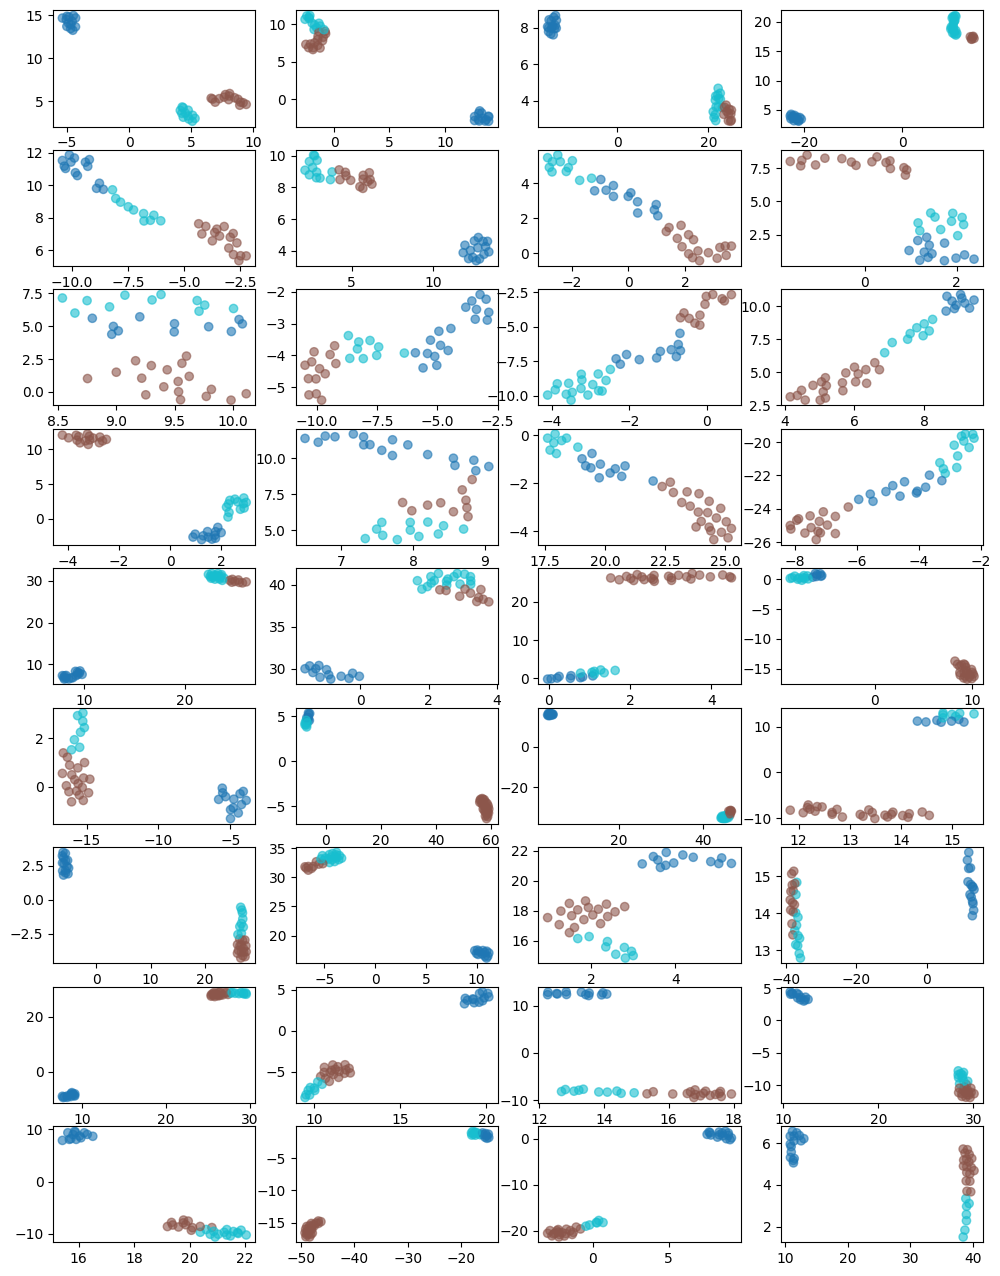

In [130]:
Z = []
embedding_list = []
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
for layer_idx in range(n_layers):
    Y, steps = get_layer_time_series(df, n_heads, layer_idx=layer_idx)
    embedding_list.append(reducer.fit_transform(Y))
    Z.extend(Y)
Z = np.array(Z)
ncol = 4
nrows = len(embedding_list) // ncol
fig, axes = plt.subplots(nrows, ncol, figsize=(12, 16))
axes = axes.flatten()[: len(embedding_list)]
for i, ax in enumerate(axes):
    embedding = embedding_list[i]
    kmeans = KMeans(n_clusters=3, random_state=42)
    cluster_labels = kmeans.fit_predict(embedding)
    # Plot with colors
    ax.scatter(
        embedding[:, 0], embedding[:, 1], c=cluster_labels, cmap="tab10", alpha=0.6
    )
    # ax.scatter(embedding[:,0], embedding[:,1], alpha=0.6)

In [136]:
Zrs = Z.reshape(n_layers, n_heads, n_steps)

In [137]:
Zrs[0].shape

(40, 154)

## Damped Oscillator fits

Bit of a bust

In [145]:
def damped_oscillator(t, A, omega, zeta):
    """
    Solve x'' + 2*zeta*omega*x' + omega^2*x = 0
    Initial conditions: x(0)=1, x'(0)=0
    """
    if zeta < 1:
        # Underdamped
        omega_d = omega * np.sqrt(1 - zeta**2)
        x = np.exp(-zeta * omega * t) * (
            np.cos(omega_d * t) + (zeta * omega / omega_d) * np.sin(omega_d * t)
        )
    elif zeta == 1:
        # Critically damped
        x = np.exp(-omega * t) * (1 + omega * t)
    else:
        # Overdamped
        s1 = -omega * (zeta + np.sqrt(zeta**2 - 1))
        s2 = -omega * (zeta - np.sqrt(zeta**2 - 1))
        c1 = -s2 / (s1 - s2)
        c2 = s1 / (s1 - s2)
        x = c1 * np.exp(s1 * t) + c2 * np.exp(s2 * t)

    return x * A

/var/folders/_5/w5f7n1zx5t521cn85gjbd2400000gn/T/ipykernel_72362/918265023.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(damped_oscillator, x, y, p0=[0.5, 2, 3e5])


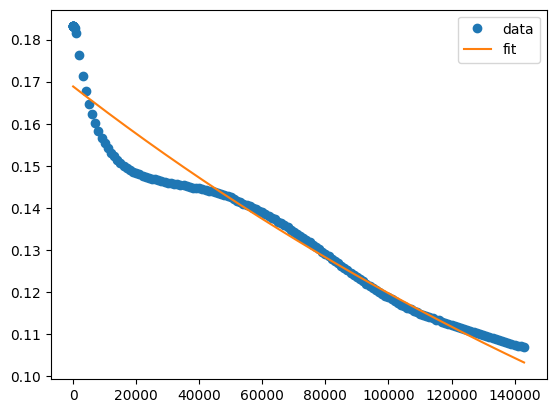

[1.68856422e-01 2.06342852e+00 3.00000000e+05]


In [153]:
x = steps
y = Zrs[4, 14]
popt, pcov = curve_fit(damped_oscillator, x, y, p0=[0.5, 2, 3e5])
plt.plot(x, y, "o", label="data")
plt.plot(x, damped_oscillator(x, *popt), "-", label="fit")
plt.legend()
plt.show()
print(popt)

## Fourier Analysis

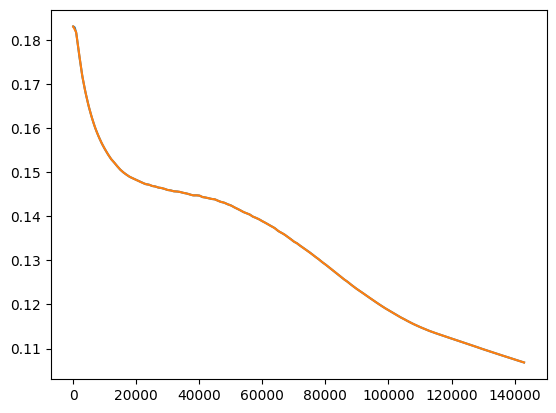

In [ ]:
from scipy.fft import fft

from scipy.interpolate import interp1d

t_uniform = np.linspace(steps[0], steps[-1], len(steps))
# For each time series
# Use as feature for clustering

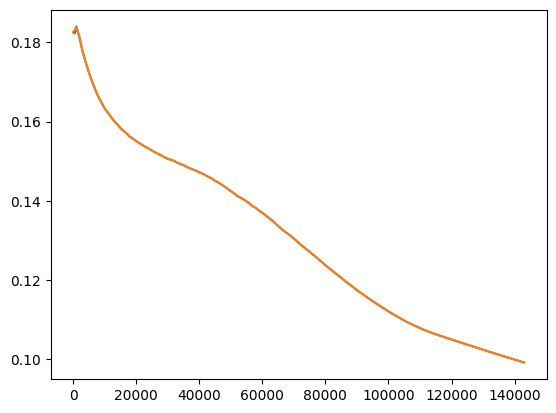

In [172]:
y = Zrs[4, 2]
interp = interp1d(steps, y, kind="cubic")
y_uniform = interp(t_uniform)
plt.plot(steps, y)
plt.plot(t_uniform, y_uniform)

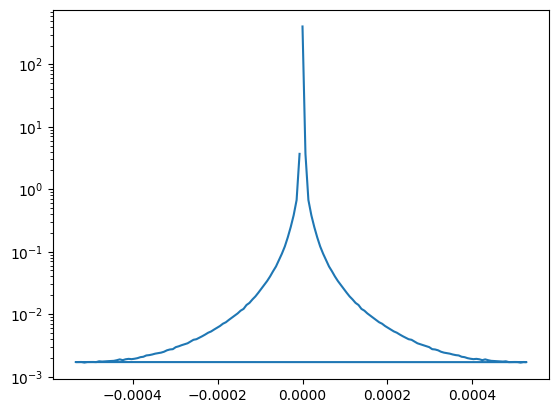

In [173]:
fft_vals = fft(y_uniform)
power = np.abs(fft_vals) ** 2
freqs = np.fft.fftfreq(len(y_uniform), d=t_uniform[1] - t_uniform[0])
plt.plot(freqs, power)
plt.yscale("log")
# Extract dominant frequency
# dominant_freq = freqs[np.argmax(power[1:])+1]  # skip DC

In [175]:
len(Z[0])

154

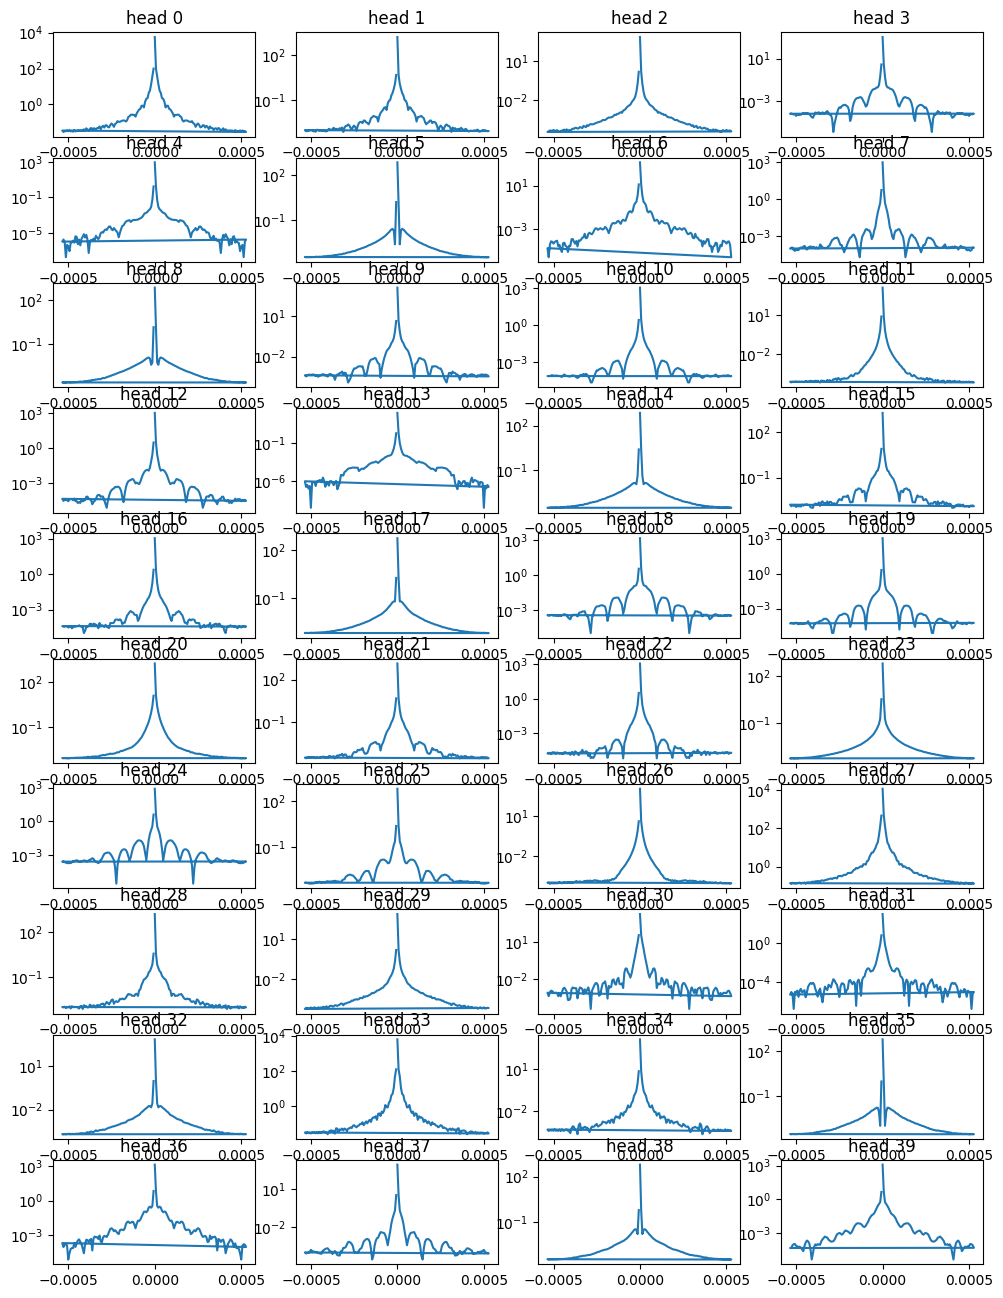

In [183]:
layer_idx = 12
ncol = 4
nrows = 10
fig, axes = plt.subplots(nrows, ncol, figsize=(12, 16))
axes = axes.flatten()
for i, ax in enumerate(axes):
    y = Zrs[layer_idx, i]
    interp = interp1d(steps, y, kind="cubic")
    y_uniform = interp(t_uniform)
    fft_vals = fft(y_uniform)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.fftfreq(len(y_uniform), d=t_uniform[1] - t_uniform[0])
    ax.plot(freqs, power)
    ax.set_yscale("log")
    ax.set_title(f"head {i}")